In [ ]:
#Import from libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error


In [ ]:
# Load dataset
df = pd.read_csv('breast-cancer.csv')

In [ ]:
# Explore dataset
print(df.info())
print(df.describe())
print("Missing values per column:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
# Drop ID because it is ireelevant to know the annonymous patients used in the sample data
df = df.drop(columns=['id'], errors='ignore')

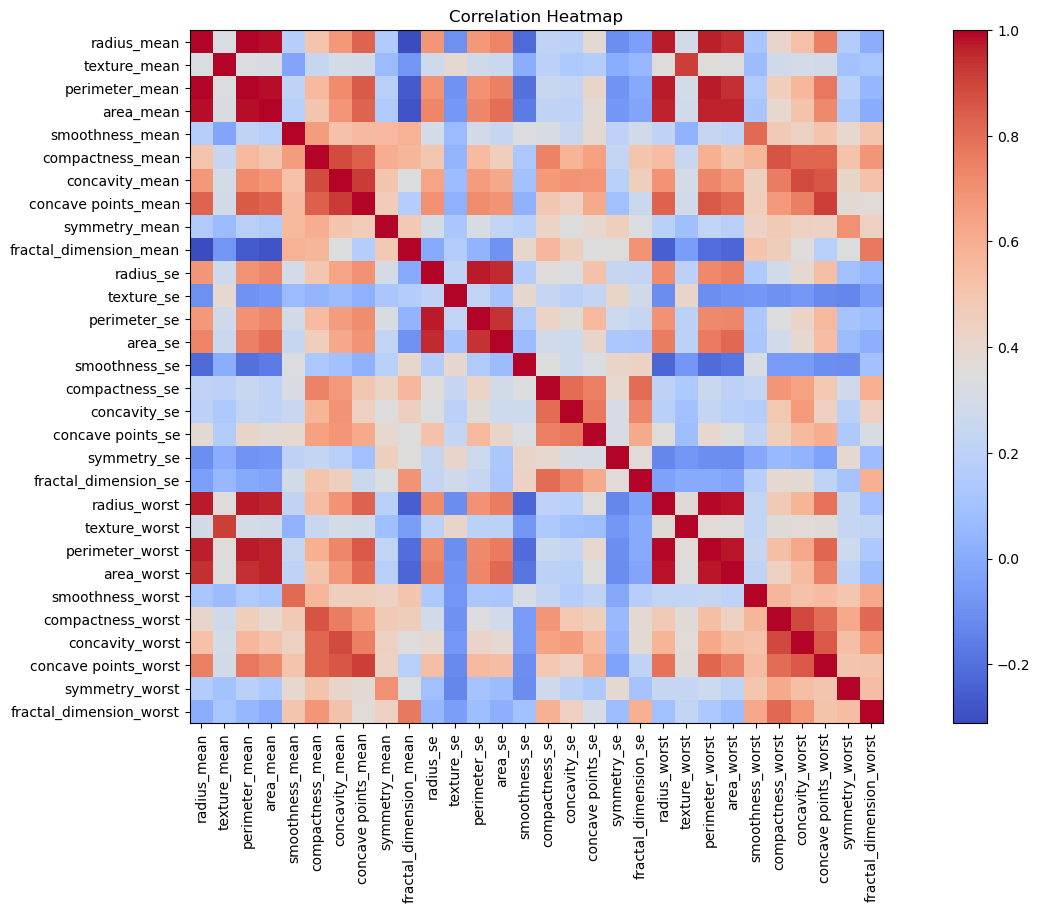

In [ ]:
# Discover and visualize the data to gain insights

# Drop non-numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix for numeric columns only
corr_matrix = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(18, 9))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Correlation Heatmap")

# Add these lines to show feature names
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)  # X-axis labels, rotated 90 degrees
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)  # Y-axis labels

plt.show()


In [ ]:
# Split dataset into train and test sets
train_set, test_set = train_test_split(df_imputed, test_size=0.2, random_state=42)

In [ ]:
# Prepare data for ML
x_train = train_set.drop('radius_mean', axis=1)
y_train = train_set['radius_mean']
x_test = test_set.drop('radius_mean', axis=1)
y_test = test_set['radius_mean']

In [ ]:
# Train model using RandomForestRegressor with cross-validation
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
cross_val_scores = cross_val_score(forest_reg, x_train, y_train, scoring='neg_mean_squared_error', cv=10)
rmse_scores = np.sqrt(-cross_val_scores)
print("Cross-Validation RMSE:", rmse_scores.mean())

Cross-Validation RMSE: 0.21544783387702887


In [ ]:
# Fine-tune the model using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': [3,5,7]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_features': 7, 'n_estimators': 50}


In [ ]:
# Evaluate model on test set
final_model = grid_search.best_estimator_
y_pred = final_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test Set RMSE:", rmse) 

Test Set RMSE: 0.2352865758355559
